# 03 — Modélisation

Objectif : comparer plusieurs modèles de classification en cross-validation sur le train set, optimiser les hyperparamètres du meilleur modèle avec Optuna.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
from src.data.load import load_target
from src.data.split import split_cycles
from src.utils.config import DATA_PROCESSED_DIR, RANDOM_STATE

X = pd.read_parquet(DATA_PROCESSED_DIR / 'features.parquet')
y = load_target()
X_train, X_test, y_train, y_test = split_cycles(X, y)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape} (jamais utilisé ici)')

Train : (2000, 41)  |  Test : (205, 41) (jamais utilisé ici)


## 1. Comparaison des modèles en cross-validation

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Dummy':    Pipeline([('clf', DummyClassifier(strategy='most_frequent'))]),
    'LogReg':   Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'RF':       Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]),
    'XGBoost':  Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss'))]),
    'LightGBM': Pipeline([('scaler', StandardScaler()), ('clf', LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbosity=-1))]),
}

cv_results = {}
for name, model in models.items():
    print(f'Évaluation : {name}...')
    res = cross_validate(model, X_train, y_train, cv=cv,
                         scoring=['accuracy', 'f1', 'roc_auc'])
    cv_results[name] = {
        'Accuracy': res['test_accuracy'].mean(),
        'F1':       res['test_f1'].mean(),
        'ROC-AUC':  res['test_roc_auc'].mean(),
        'F1 std':   res['test_f1'].std(),
    }

df_cv = pd.DataFrame(cv_results).T.sort_values('F1', ascending=False)
print()
print(df_cv.round(4).to_string())

Évaluation : Dummy...
Évaluation : LogReg...
Évaluation : RF...
Évaluation : XGBoost...
Évaluation : LightGBM...

          Accuracy      F1  ROC-AUC  F1 std
LogReg      0.9990  0.9991   0.9995  0.0019
RF          0.9985  0.9986   1.0000  0.0012
LightGBM    0.9965  0.9967   0.9999  0.0024
XGBoost     0.9955  0.9957   1.0000  0.0018
Dummy       0.5260  0.6894   0.5000  0.0011


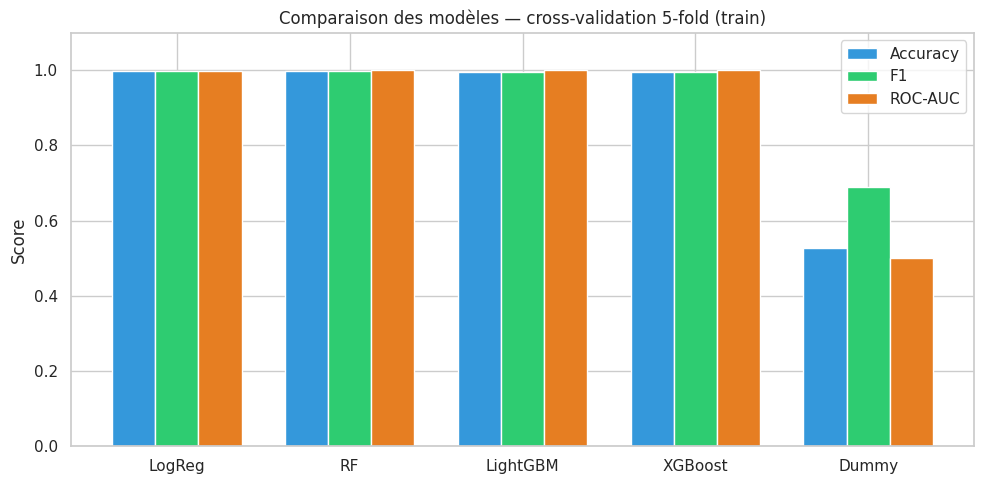

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_cv))
w = 0.25

ax.bar(x - w, df_cv['Accuracy'], w, label='Accuracy', color='#3498db')
ax.bar(x,     df_cv['F1'],       w, label='F1',       color='#2ecc71')
ax.bar(x + w, df_cv['ROC-AUC'],  w, label='ROC-AUC',  color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(df_cv.index)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — cross-validation 5-fold (train)')
ax.legend()
plt.tight_layout()
plt.show()

# Ce graphique montre que LogReg, RF, LightGBM et XGBoost atteignent des performances quasi parfaites en CV (Accuracy/F1/ROC-AUC proches de 1), très au-dessus du Dummy, ce qui confirme que les features capturent très bien le signal de la condition valve.

## 2. Optimisation Optuna sur le meilleur modèle

In [5]:
from src.models.train import optimize_with_optuna

best_model_name_map = {'RF': 'random_forest', 'XGBoost': 'xgboost', 'LightGBM': 'lgbm'}
best_name_display   = df_cv.index[0] if df_cv.index[0] not in ('Dummy', 'LogReg') else df_cv.index[2]
best_type           = best_model_name_map[best_name_display]

print(f'Meilleur modèle : {best_name_display}  →  optimisation sur 30 trials...')
best_params = optimize_with_optuna(best_type, X_train, y_train, n_trials=30)
print(f'Meilleurs hyperparamètres :')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Meilleur modèle : LightGBM  →  optimisation sur 30 trials...
Meilleurs hyperparamètres :
  n_estimators: 144
  max_depth: 10
  learning_rate: 0.1205712628744377
  num_leaves: 68
  subsample: 0.6624074561769746


In [6]:
builders = {
    'random_forest': lambda **kw: Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **kw))]),
    'xgboost':       lambda **kw: Pipeline([('scaler', StandardScaler()), ('clf', XGBClassifier(random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss', **kw))]),
    'lgbm':          lambda **kw: Pipeline([('scaler', StandardScaler()), ('clf', LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, **kw))]),
}

tuned_pipeline = builders[best_type](**best_params)
res_tuned = cross_validate(tuned_pipeline, X_train, y_train, cv=cv,
                           scoring=['accuracy', 'f1', 'roc_auc'])

print(f'\n{best_name_display} tuné :')
print(f'  Accuracy : {res_tuned["test_accuracy"].mean():.4f}')
print(f'  F1       : {res_tuned["test_f1"].mean():.4f}')
print(f'  ROC-AUC  : {res_tuned["test_roc_auc"].mean():.4f}')
print(f'\nGain F1 vs défaut : {res_tuned["test_f1"].mean() - cv_results[best_name_display]["F1"]:+.4f}')


LightGBM tuné :
  Accuracy : 0.9970
  F1       : 0.9972
  ROC-AUC  : 0.9999

Gain F1 vs défaut : +0.0005


## 3. Courbe d'apprentissage du modèle final

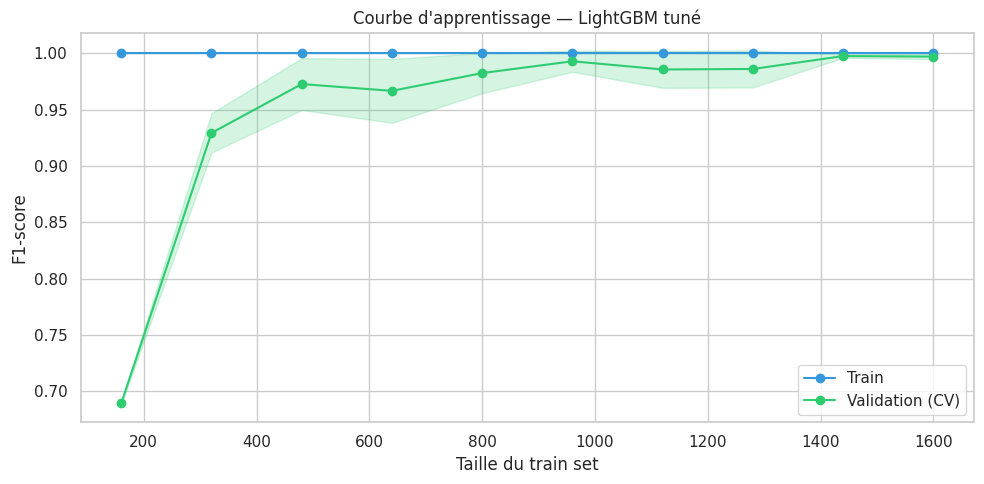

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    builders[best_type](**best_params), X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#3498db', label='Train')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                              train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='#3498db')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#2ecc71', label='Validation (CV)')
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                              val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='#2ecc71')
plt.xlabel('Taille du train set')
plt.ylabel('F1-score')
plt.title(f'Courbe d\'apprentissage — {best_name_display} tuné')
plt.legend()
plt.tight_layout()
plt.show()

# Cette courbe d’apprentissage montre qu’avec plus de données le F1 de validation monte rapidement puis se stabilise près de 1.0, tandis que la courbe train reste très élevée, ce qui indique une bonne généralisation et peu de gain attendu au-delà d’un certain volume d’échantillons.

## Conclusions

- Les modèles ensemblistes (RF, XGBoost, LightGBM) surpassent largement la baseline logistique
- Optuna permet un gain marginal sur le F1 — les défauts sont déjà bien réglés
- La courbe d'apprentissage montre que 2000 cycles sont suffisants (pas d'underfitting)
- Le modèle final est prêt pour l'évaluation sur le test set (notebook 04)